In [85]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Cleaning Data
#### วิธีทำ
1. Load data
2. Data Reshaping (Pivot Table)
3.  Return Transformation (Daily Log Returns)
4.  Handling Missing Values (ตัดหุ้นที่มีค่าว่างออก)
5.  Standardization & Transpose (ปรับสเกลและสลับมิติให้หุ้นเป็น Samples พร้อมเข้าโมเดล)

In [133]:
# step 1 
df = pd.read_csv('NASDAQ-100/NASDAQ_100_Data_From_2010.csv', sep='\t')
df['Date'] = pd.to_datetime(df['Date'])

# step 2
price_matrix = df.pivot(index='Date', columns='Name', values='Adj Close')

#step 3 
returns_matrix = np.log(price_matrix / price_matrix.shift(1)).iloc[1:]

# step 4 
clean_returns = returns_matrix.dropna(axis=1)

# step 5 
scaler = StandardScaler()
X = scaler.fit_transform(clean_returns)
# X = scaler.fit_transform(clean_returns).T


stock_names = clean_returns.columns.tolist()
print(stock_names)
print("จำนวนหุ้น: ", len(stock_names))
print(f"ขนาดของข้อมูล: {X.shape}")

['AAPL', 'ADBE', 'ADI', 'ADP', 'ADSK', 'AEP', 'ALGN', 'AMAT', 'AMD', 'AMGN', 'AMZN', 'ANSS', 'ASML', 'ATVI', 'AVGO', 'BIDU', 'BIIB', 'BKNG', 'CDNS', 'CERN', 'CHKP', 'CMCSA', 'COST', 'CPRT', 'CSCO', 'CSX', 'CTAS', 'CTSH', 'DLTR', 'DXCM', 'EA', 'EBAY', 'EXC', 'FAST', 'FISV', 'GILD', 'GOOG', 'GOOGL', 'HON', 'IDXX', 'ILMN', 'INCY', 'INTC', 'INTU', 'ISRG', 'KDP', 'KLAC', 'LRCX', 'LULU', 'MAR', 'MCHP', 'MDLZ', 'MELI', 'MNST', 'MRVL', 'MSFT', 'MTCH', 'MU', 'NFLX', 'NTES', 'NVDA', 'ORLY', 'PAYX', 'PCAR', 'PEP', 'QCOM', 'REGN', 'ROST', 'SBUX', 'SGEN', 'SIRI', 'SNPS', 'SWKS', 'TCOM', 'TMUS', 'TXN', 'VRSK', 'VRSN', 'VRTX', 'WBA', 'XEL', 'XLNX']
จำนวนหุ้น:  82
ขนาดของข้อมูล: (2942, 82)


## T-SNE
#### วิธีการทำ
1. กำหนดค่าพารามิเตอร์ของ t-SNE
    - perplexity: ค่าความหนาแน่นเพื่อนบ้าน (ปกติแนะนำช่วง 5 - 50 ขึ้นอยู่กับจำนวนหุ้น)
    - random_state: เพื่อให้ผลลัพธ์นิ่งเหมือนเดิมทุกครั้งที่กดรัน
2. แปลงข้อมูล X (มิติเดิมคือ [Dates, Stocks] แต่ t-SNE ต้องสลับให้หุ้นเป็น Sample)
    - เราใช้ X.T เพราะ t-SNE ต้องการข้อมูลในรูป (จำนวนหุ้น, จำนวนวัน) เพื่อหาความสัมพันธ์ระหว่างหุ้น

In [134]:
from sklearn.manifold import TSNE

In [171]:
# step 1 
tsne = TSNE(n_components=2, perplexity=5, random_state=42, max_iter=1000)

# step 2 
X_stock_view = X.T

tsne_features = tsne.fit_transform(X_stock_view)

tsne_df = pd.DataFrame(
    tsne_features,
    index=clean_returns.columns,
    columns=['Dim1', 'Dim2']
)

tsne_df.head()

,Dim1,Dim2
Name,,
AAPL,9.595278,-1.796184
ADBE,6.439882,1.135665
ADI,23.381592,13.423829
ADP,-10.243598,-16.394571
ADSK,5.039843,2.567079


# หาค่า KMeans ด้วยตัวเอง 
#### วิธีที่ 1 Elbow Method ขั้นตอนการทำ
1. ลองรัน K-Means ตั้งแต่ k = 1 ถึง 10
3. พล็อตกราฟ Elbow

In [172]:
from sklearn.cluster import KMeans

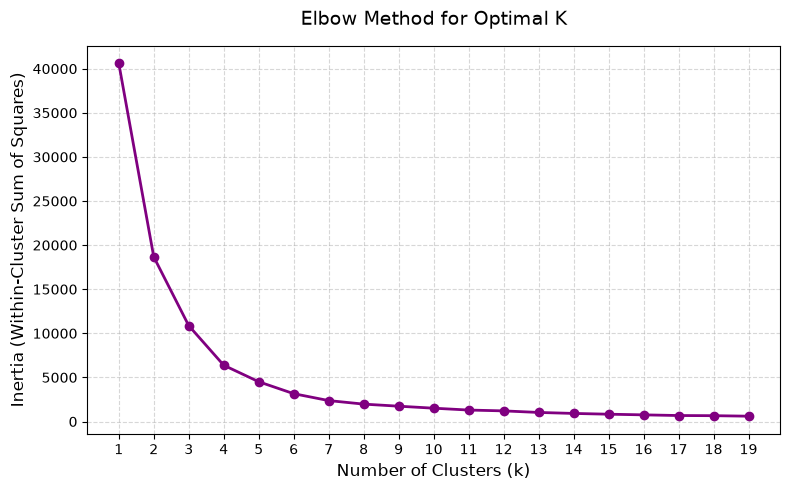

In [173]:

# step 1
inertia = []
K_range = range(1, 20)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(tsne_df[['Dim1', 'Dim2']])
    inertia.append(kmeans.inertia_)

# step 2
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', color='purple', linewidth=2)
plt.title('Elbow Method for Optimal K', fontsize=14, pad=15)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(K_range)
plt.tight_layout() 

plt.show()

## วิธีที่ 2: ใช้ Silhouette Score 
#### วิธีการทำ
1. Silhouette เริ่มต้นที่ k=2
2. คำนวณคะแนน Silhouette
3. หาค่า k ที่ให้คะแนนสูงสุด
4. พล็อตกราฟดูคะแนนแต่ละ k

In [174]:
from sklearn.metrics import silhouette_score

ค่า K ที่เหมาะสมที่สุดตาม Silhouette Score is: 7 (คะแนนสูงสุด: 0.5927)


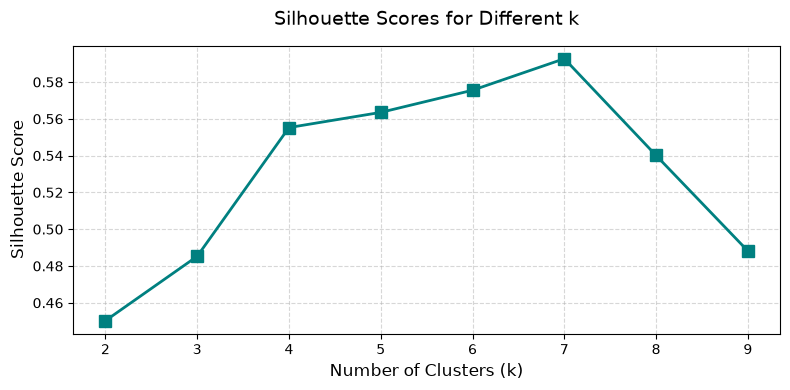

In [175]:
# step 1
silhouette_score1 = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(tsne_df[['Dim1', 'Dim2']])

    # step 2 
    score = silhouette_score(tsne_df[['Dim1', 'Dim2']], labels)
    silhouette_score1.append(score)

# step 3 
best_k = K_range[np.argmax(silhouette_score1)]
print(f"ค่า K ที่เหมาะสมที่สุดตาม Silhouette Score is: {best_k} (คะแนนสูงสุด: {max(silhouette_score1):.4f})")

# step 4 
plt.figure(figsize=(8, 4))
plt.plot(K_range, silhouette_score1, marker='s', color='teal', linewidth=2, markersize=8)
plt.title('Silhouette Scores for Different k', fontsize=14, pad=15)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## วาดกราฟ Scatter Plot กรณีที่ยังไม่ได้ทำ KMeans
#### วิธีทำ
1. พล็อตจุดทั้งหมด
2. วนลูปใส่ชื่อย่อหุ้นกำกับแต่ละจุด

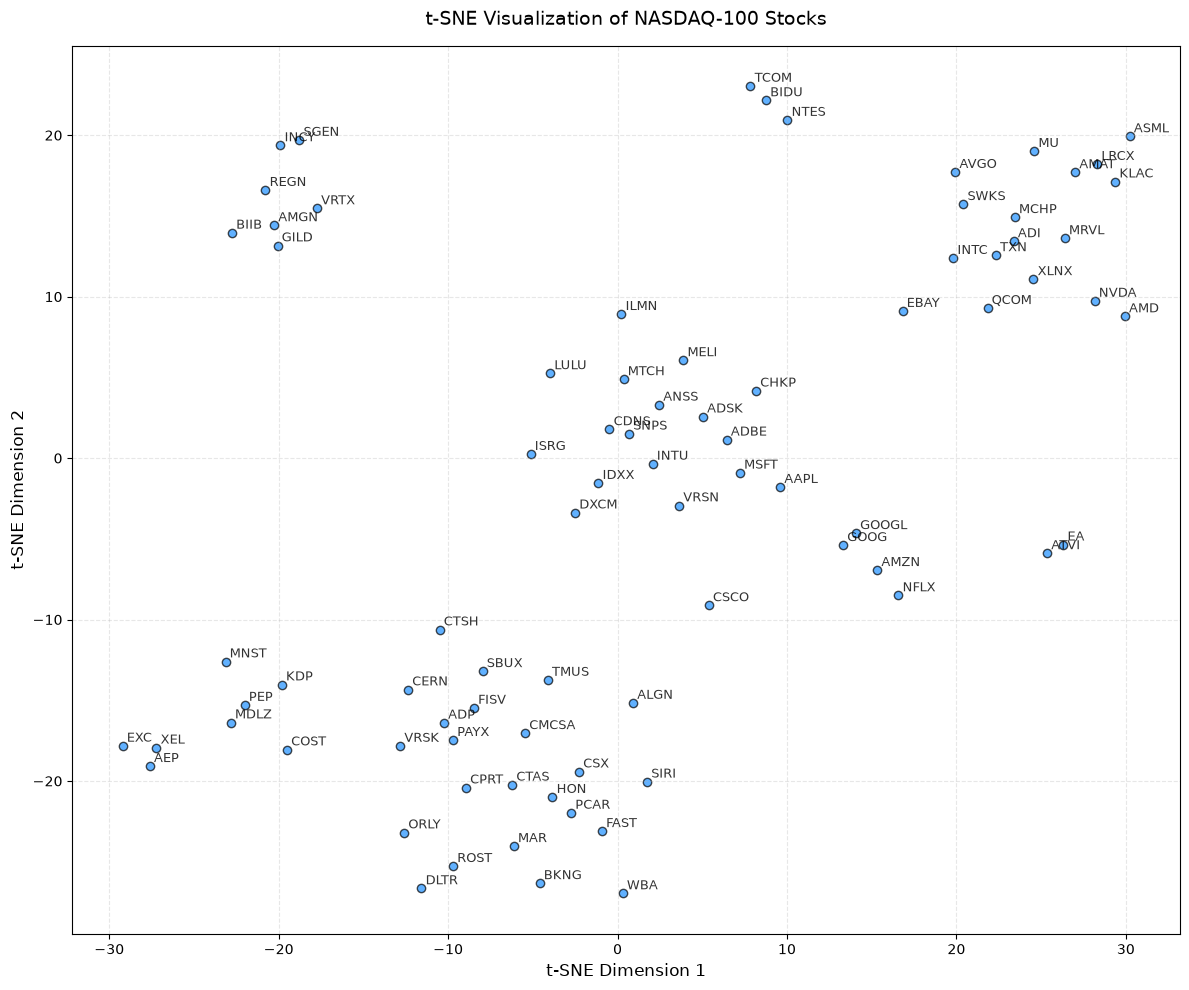

In [176]:
# step 1 
plt.figure(figsize=(12, 10))
plt.scatter(tsne_df['Dim1'], tsne_df['Dim2'], alpha=0.7, color='dodgerblue', edgecolors='k')

# step 2 
for stock_names, row in tsne_df.iterrows():
    plt.annotate(
        stock_names, 
        (row['Dim1'], row['Dim2']),
        fontsize=9,
        alpha=0.8,
        xytext=(3, 3),
        textcoords='offset points'
    )

plt.title('t-SNE Visualization of NASDAQ-100 Stocks', fontsize=14, pad=15)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

# กราฟ Scatter Plot กรณีที่หา KMeans ได้แล้ว
#### วิธีทำ
1. ใช้ K-Means จัดกลุ่มหุ้นออกเป็น k กลุ่ม
2. ใช้ Colormap เพื่อให้แต่ละ Cluster ได้สีต่างกันชัดเจน
3. วนลูปใส่ชื่อย่อหุ้นกำกับแต่ละจุด
4. พล้อตกราฟ

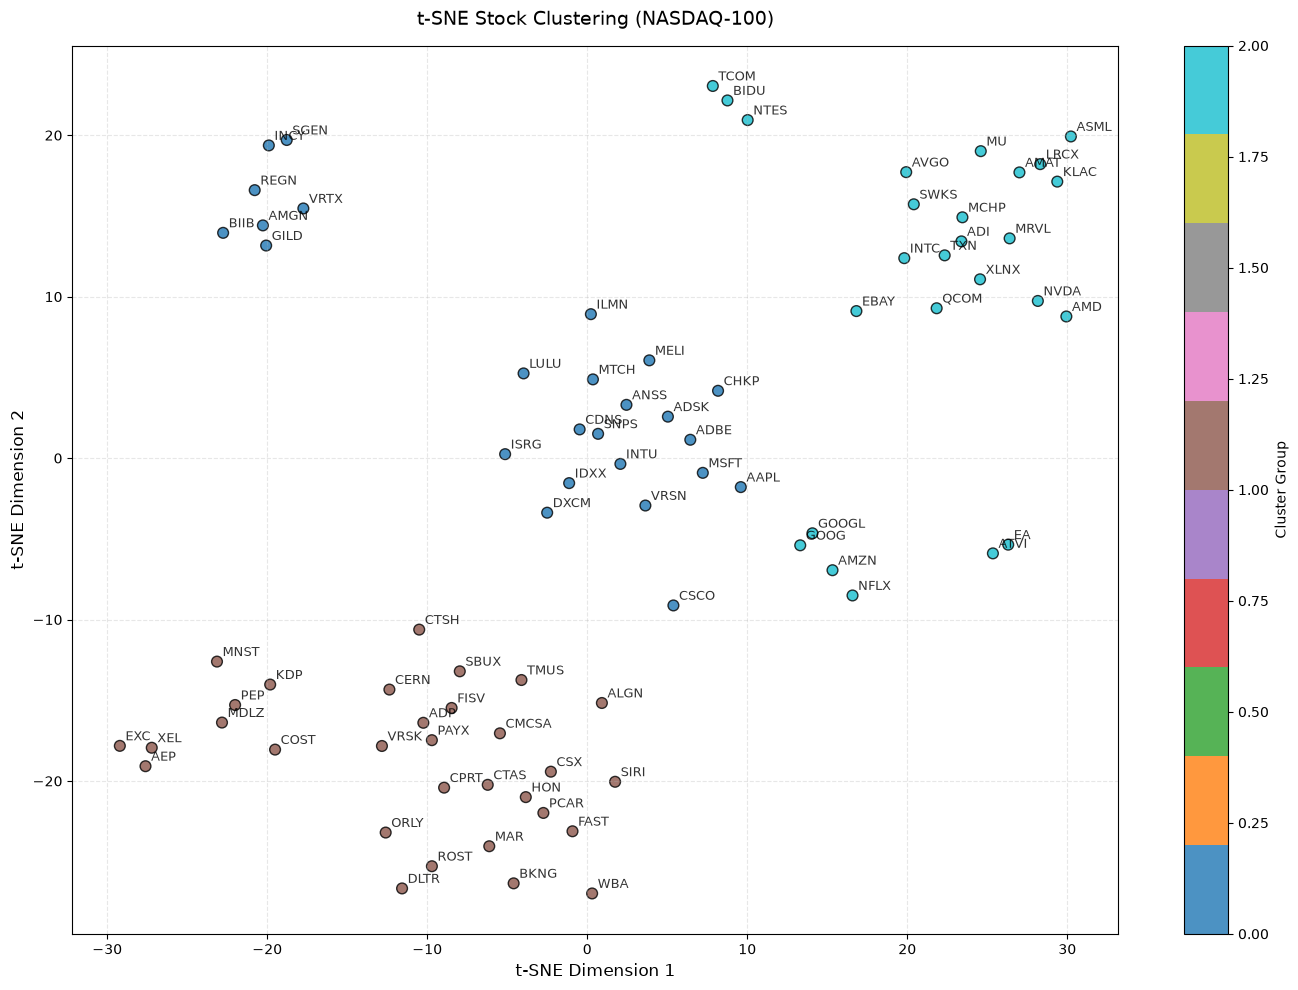


       t-SNE + K-Means SUMMARY
จำนวนหุ้นทั้งหมด: 82
จำนวน Cluster (K): 3


In [177]:

# step 1 
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
tsne_df['Cluster'] = kmeans.fit_predict(tsne_df[['Dim1', 'Dim2']])
tsne_df.head()

# step 2 
plt.figure(figsize=(14, 10))
scatter = plt.scatter(
    tsne_df['Dim1'],
    tsne_df['Dim2'],
    c=tsne_df['Cluster'],
    cmap='tab10',
    s=60,
    alpha=0.8,
    edgecolors='k'
)

# step 2 
for stock, row in tsne_df.iterrows():
    plt.annotate(
        stock,
        (row['Dim1'], row['Dim2']),
        fontsize=9,
        alpha=0.8,
        xytext=(4, 4),
        textcoords='offset points'
    )

# step 3
plt.title('t-SNE Stock Clustering (NASDAQ-100)', fontsize=14, pad=15)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.colorbar(scatter, label='Cluster Group')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

print("\n======================================")
print("       t-SNE + K-Means SUMMARY")
print("======================================")
print(f"จำนวนหุ้นทั้งหมด: {len(tsne_df)}")
print(f"จำนวน Cluster (K): {n_clusters}")
print("======================================")

# Clean data ด้วย PCA และใช้ T-SNE รวมกับ KMeans
#### วิธีการทำ
1. ทำ PCA ก่อน
2. นำ PCA Features มาเข้า t-SNE เพื่อบีบอัดเหลือ 2 มิติสำหรับวาดกราฟ
   - เนื่องจาก pca_features มีแถวเป็น "วัน" และคอลัมน์เป็น "PC"
   - เราจึงต้องสลับมิติ (.T) ให้แถวกลายเป็น "หุ้น" ก่อนส่งเข้า t-SNE
3. นำมาใส่ DataFrame
4. เราจะหาค่า K ก่อน
5. ทำ K-Means จัดกลุ่มจากพิกัด t-SNE ที่ได้
6. พล็อตกราฟแสดงผล

In [178]:
# step 1 
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(X.T)

# step 2 
tsne = TSNE(n_components=2, perplexity=10, random_state=42)
tsne_features = tsne.fit_transform(pca_features)

# step 3 
tsne_df2 = pd.DataFrame(
    tsne_features,
    index=clean_returns.columns,
    columns=['Dim1', 'Dim2']
)
tsne_df2.head()

,Dim1,Dim2
Name,,
AAPL,6.412940,-6.191206
ADBE,5.607585,-2.819128
ADI,15.189647,-16.476847
ADP,-17.540379,-2.905344
ADSK,8.174575,-6.145655


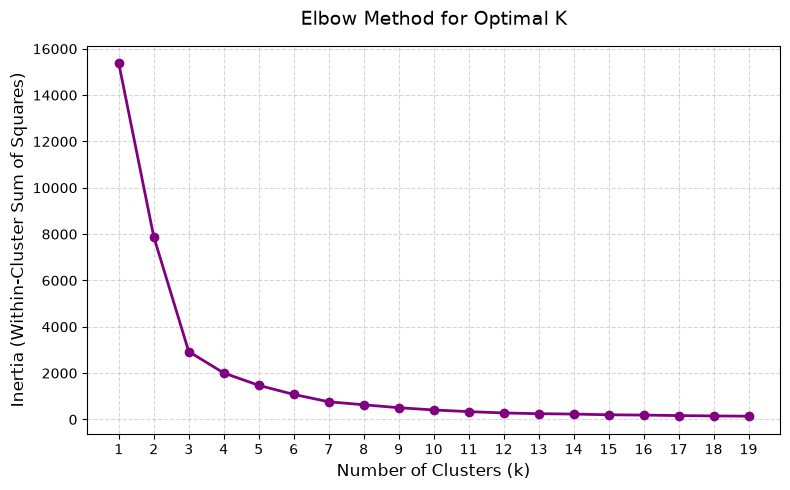

In [179]:
# step 4 

inertia = []
K_range = range(1, 20)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(tsne_df2[['Dim1', 'Dim2']])
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', color='purple', linewidth=2)
plt.title('Elbow Method for Optimal K', fontsize=14, pad=15)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(K_range)
plt.tight_layout() 

plt.show()

ค่า K ที่เหมาะสมที่สุดตาม Silhouette Score is: 3 (คะแนนสูงสุด: 0.5900)


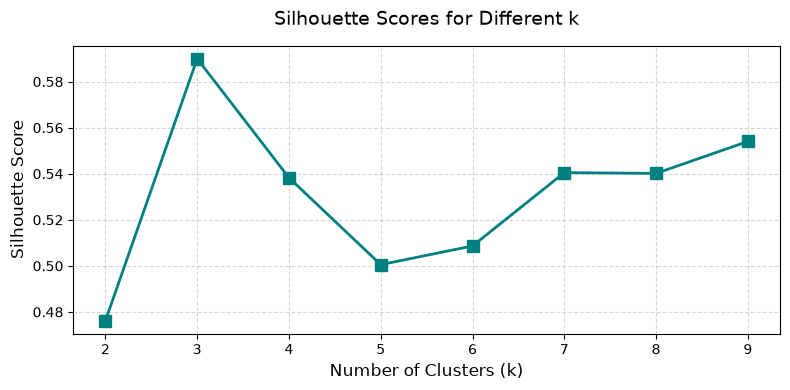

In [180]:
# step 4 วิธีที่ 2 

silhouette_score1 = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(tsne_df2[['Dim1', 'Dim2']])


    score = silhouette_score(tsne_df2[['Dim1', 'Dim2']], labels)
    silhouette_score1.append(score)


best_k = K_range[np.argmax(silhouette_score1)]
print(f"ค่า K ที่เหมาะสมที่สุดตาม Silhouette Score is: {best_k} (คะแนนสูงสุด: {max(silhouette_score1):.4f})")


plt.figure(figsize=(8, 4))
plt.plot(K_range, silhouette_score1, marker='s', color='teal', linewidth=2, markersize=8)
plt.title('Silhouette Scores for Different k', fontsize=14, pad=15)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [181]:
# step 5 
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
tsne_df2['Cluster'] = kmeans.fit_predict(tsne_df2[['Dim1', 'Dim2']])

 กลุ่ม Cluster 0 (จำนวน 32 ตัว):


 กลุ่ม Cluster 1 (จำนวน 29 ตัว):


 กลุ่ม Cluster 2 (จำนวน 21 ตัว):




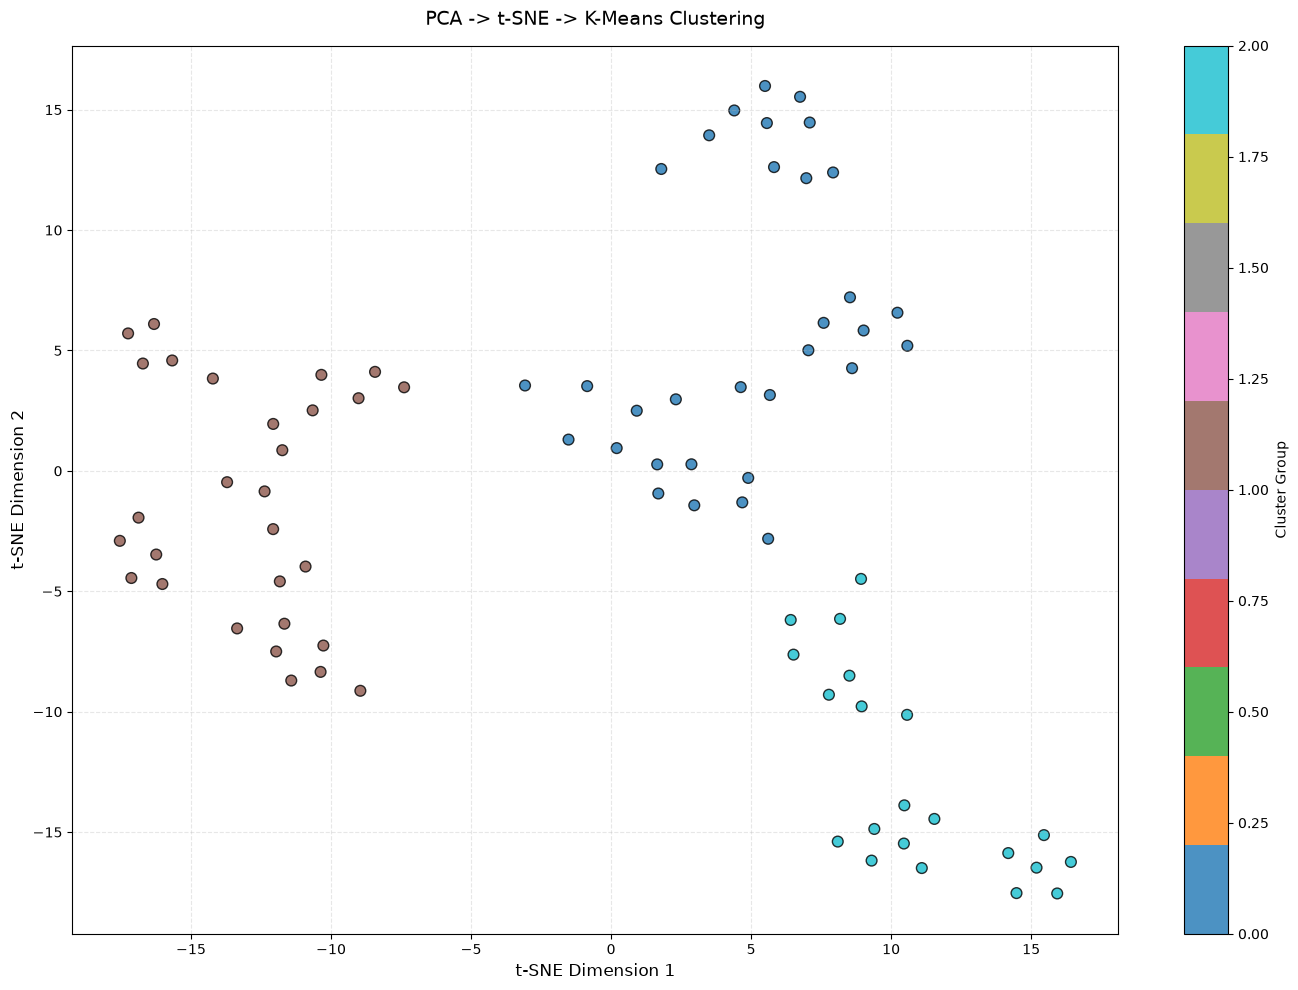

In [182]:
# step 6 
plt.figure(figsize=(14, 10))
scatter = plt.scatter(
    tsne_df2['Dim1'],
    tsne_df2['Dim2'],
    c=tsne_df2['Cluster'],
    cmap='tab10',
    s=60,
    alpha=0.8,
    edgecolors='k'
)

for cluster_id in sorted(tsne_df2['Cluster'].unique()):
    
    # กรองเอาเฉพาะหุ้นที่อยู่ใน Cluster นั้นๆ
    stock_in_cluster = tsne_df2[tsne_df2['Cluster'] == cluster_id].index.tolist()

    # ดึงชื่อสีออกมาแสดง
    color_label = color_names[cluster_id] if cluster_id < len(color_names) else f"Cluster {cluster_id}"
    
    print(f"========================================")
    print(f" กลุ่ม Cluster {cluster_id} (จำนวน {len(stock_in_cluster)} ตัว):")
    print(f"========================================")
    print("\n")

    
plt.title('PCA -> t-SNE -> K-Means Clustering', fontsize=14, pad=15)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.colorbar(scatter, label='Cluster Group')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()